# Episode 4 — Bayesian Optimization, Explained

📺 *Part of the [Heatsink Optimization Series](../README.md)*

A tiny, hands-on notebook that builds the intuition for **Bayesian optimization (BO)** — what it is, why it beats brute force when every evaluation is expensive, and how we point it at our heatsink. Run the cells to draw the sketches.

> No CFD here — just the idea. **Episode 5** runs the real thing.

In [2]:
import warnings, logging
import numpy as np
import matplotlib.pyplot as plt

# quiet the harmless "font not found" warnings from the hand-drawn (xkcd) style
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# whiteboard palette (matches the series)
INK, RED, BLUE = "#1a1a1a", "#c0392b", "#2471a3"
GREEN, ORANGE, PURPLE, GREY = "#1e8449", "#ca6f1e", "#7d3c98", "#7f8c8d"
np.random.seed(7)

# The (secret) expensive objective we are trying to MAXIMISE.
# In reality this is Q/V, and one evaluation = one ~8-minute CFD run.
def true_objective(x):
    return np.sin(3 * x) + 0.5 * np.sin(7 * x) - 0.9 * (x - 0.5) ** 2

X = np.linspace(0, 1, 400)
print("setup done — the objective is hidden; we can only sample it a few times")

setup done — the objective is hidden; we can only sample it a few times


## 1. The problem — an expensive black box

Our objective is **Q/V**, and the only way to evaluate it for a given design is to run a full CFD simulation — roughly **8 minutes each**. A grid search over (N, t, H) would be *days* of compute. So we can only afford a **handful** of samples, and we have to be clever about *which* designs we try.

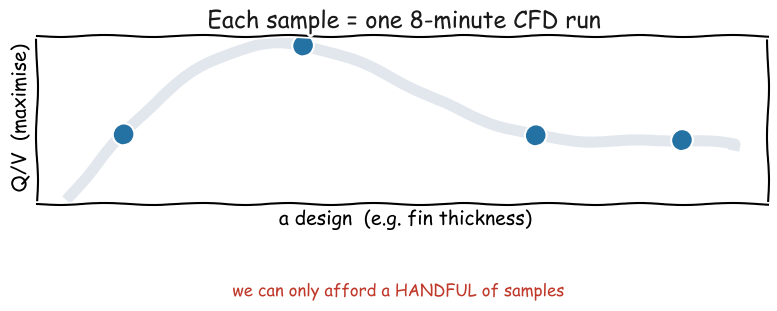

In [9]:
with plt.xkcd():
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(X, true_objective(X), color="#cfd8e3", lw=8, alpha=0.6)   # the hidden truth (faint)
    xs = np.array([0.08, 0.35, 0.7, 0.92])
    ax.plot(xs, true_objective(xs), "o", color=BLUE, ms=13)
    ax.set_title("Each sample = one 8-minute CFD run", color=INK)
    ax.set_xlabel("a design  (e.g. fin thickness)")
    ax.set_ylabel("Q/V  (maximise)")
    ax.text(0.5, -1.15, "we can only afford a HANDFUL of samples",
            ha="center", color=RED, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

## 2. What *is* Bayesian optimization?

In one breath: **Bayesian optimization finds the best input to an expensive function using as few tries as possible** — by keeping a *belief* about the objective and **updating that belief every time it gets a new result**. It doesn't follow a fixed plan like a grid; it learns as it goes and always spends the next run where it expects to learn the most.

Why *"Bayesian"*? It comes from **Bayes' rule** — the formal name for something you already do: when new evidence arrives, you update what you believe.

- **Prior** — your belief *before* seeing data (flat, very uncertain).
- **Observe** — run a design, measure Q/V.
- **Posterior** — your *updated* belief. It then becomes the prior for the next round. Repeat.

Think of a doctor: a hunch from the symptoms (prior) → one test (observation) → a revised diagnosis (posterior). The plot below shows the same idea for our objective.


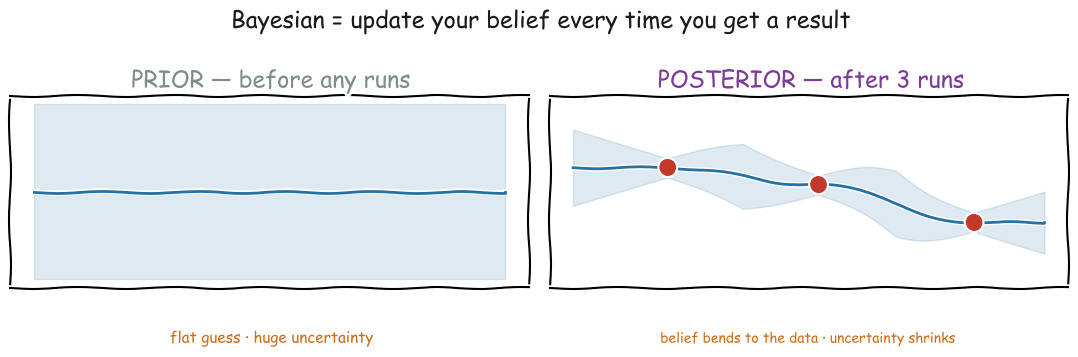

In [10]:
# "Bayesian" = update a BELIEF with each result.
#   LEFT  : the PRIOR      — before any runs, a flat guess with huge uncertainty.
#   RIGHT : the POSTERIOR  — after 3 runs, the belief bends to the data and the
#           uncertainty shrinks right where we measured.
xs3 = np.array([0.20, 0.52, 0.85])
ys3 = true_objective(xs3)

def belief(Xte, Xtr, ytr, length=0.16):
    """A light-weight stand-in for a posterior: smooth mean through the points
    plus an uncertainty band that pinches to ~0 at the data and widens away."""
    w    = np.exp(-((Xte[:, None] - Xtr[None, :]) / length) ** 2)
    mean = (w @ ytr) / w.sum(1)
    near = np.min(np.abs(Xte[:, None] - Xtr[None, :]), axis=1)
    band = np.clip(0.12 + 1.8 * near, 0.12, 1.1)
    return mean, band

with plt.xkcd():
    fig, (pa, pb) = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)

    # PRIOR — flat mean, wide flat band
    flat = np.full_like(X, ys3.mean())
    pa.fill_between(X, flat - 1.1, flat + 1.1, color=BLUE, alpha=0.15)
    pa.plot(X, flat, color=BLUE, lw=2)
    pa.plot([], [], " ", label="no data yet")
    pa.set_title("PRIOR — before any runs", color=GREY)
    pa.text(0.5, ys3.mean() - 1.9, "flat guess · huge uncertainty",
            ha="center", color=ORANGE, fontsize=11)

    # POSTERIOR — belief bent to the 3 observed points
    m, b = belief(X, xs3, ys3)
    pb.fill_between(X, m - b, m + b, color=BLUE, alpha=0.15)
    pb.plot(X, m, color=BLUE, lw=2)
    pb.plot(xs3, ys3, "o", color=RED, ms=11)
    pb.set_title("POSTERIOR — after 3 runs", color=PURPLE)
    pb.text(0.5, ys3.mean() - 1.9, "belief bends to the data · uncertainty shrinks",
            ha="center", color=ORANGE, fontsize=10)

    for ax in (pa, pb):
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Bayesian = update your belief every time you get a result", color=INK)
    plt.tight_layout(); plt.show()


## 3. The surrogate — a cheap stand-in

The idea: from the few (design → Q/V) pairs we *have* measured, fit a cheap statistical model that **predicts** Q/V everywhere — with an honest sense of its own **uncertainty**.

Below is a tiny [Gaussian-process](https://en.wikipedia.org/wiki/Gaussian_process) surrogate: it's confident near the samples and unsure far from them.

> **This is the posterior from Section 2, made concrete.** The GP mean **and its band together *are* the updated belief.** With no data the GP is the *prior* — a flat mean and a huge uniform band. Each sample is one piece of evidence: Bayes' rule pulls the mean toward it and collapses the band around it. A Gaussian process is simply Bayes' rule applied to a whole function at once.


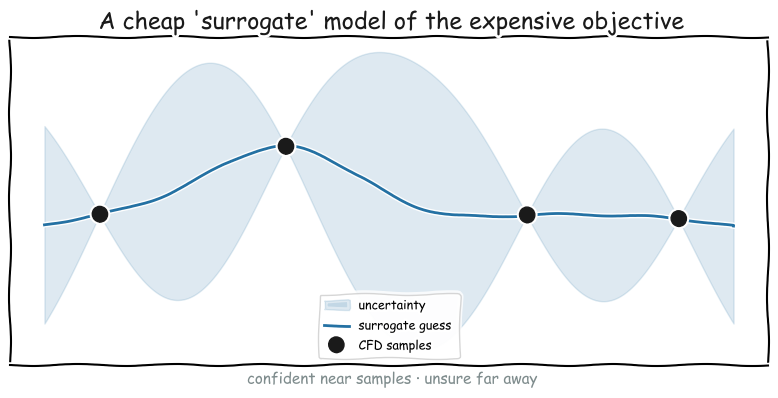

In [11]:
def gp_posterior(Xtr, ytr, Xte, length=0.12, sig=1.0, noise=1e-4):
    """Minimal squared-exponential Gaussian-process posterior (mean + std)."""
    kern = lambda a, b: sig**2 * np.exp(-0.5 * ((a[:, None] - b[None, :]) / length) ** 2)
    K   = kern(Xtr, Xtr) + noise * np.eye(len(Xtr))
    Ks  = kern(Xte, Xtr)
    Kss = kern(Xte, Xte)
    Kinv = np.linalg.inv(K)
    mu  = Ks @ Kinv @ ytr
    var = np.clip(np.diag(Kss - Ks @ Kinv @ Ks.T), 0, None)
    return mu, np.sqrt(var)

xs = np.array([0.08, 0.35, 0.7, 0.92]); ys = true_objective(xs)
mu, sd = gp_posterior(xs, ys, X)

with plt.xkcd():
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.fill_between(X, mu - 2*sd, mu + 2*sd, color=BLUE, alpha=0.15, label="uncertainty")
    ax.plot(X, mu, color=BLUE, lw=2, label="surrogate guess")
    ax.plot(xs, ys, "o", color=INK, ms=11, label="CFD samples")
    ax.set_title("A cheap 'surrogate' model of the expensive objective", color=INK)
    ax.text(0.5, -1.7, "confident near samples · unsure far away",
            ha="center", color=GREY, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=9, loc="lower center")
    plt.tight_layout(); plt.show()

## 4. The acquisition function — explore vs. exploit

At every design the surrogate gives us two numbers: how **good** it's predicted to be (the mean) and how **uncertain** we are (the spread). The *acquisition function* blends them —

$$\text{acquisition} = \underbrace{\text{mean}}_{\text{exploit}} \; + \; \kappa \cdot \underbrace{\text{uncertainty}}_{\text{explore}}$$

— and its **peak** is the single best design to sample next. This simple form is **Upper Confidence Bound (UCB)**.

> The one you'll meet most often in the literature is **Expected Improvement (EI)**: instead of a weighted sum, it asks *"across all the ways this design might turn out, what is the expected amount by which it beats the best result so far?"* Same job, a more principled score. **Remember EI** — the TPE sampler in Section 6 is built to maximise exactly it.


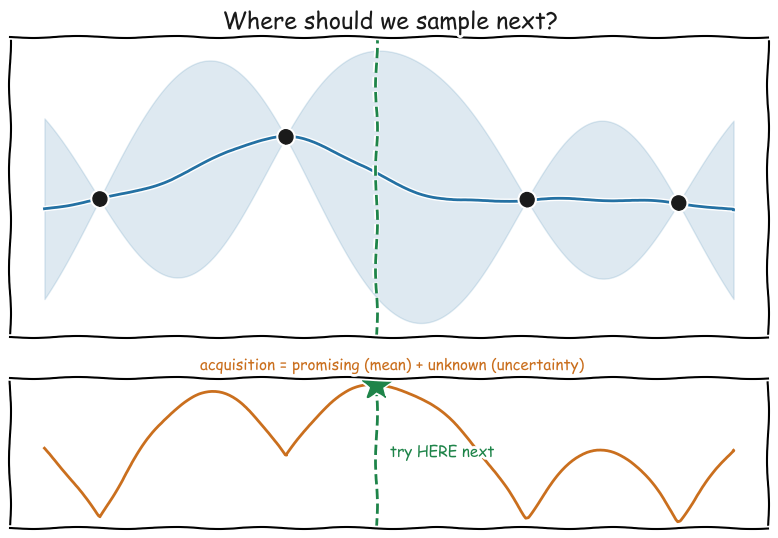

In [12]:
kappa = 1.8
acq = mu + kappa * sd
nxt = X[np.argmax(acq)]

with plt.xkcd():
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]})
    a1.fill_between(X, mu - 2*sd, mu + 2*sd, color=BLUE, alpha=0.15)
    a1.plot(X, mu, color=BLUE, lw=2)
    a1.plot(xs, ys, "o", color=INK, ms=10)
    a1.axvline(nxt, color=GREEN, ls="--")
    a1.set_title("Where should we sample next?", color=INK)
    a1.set_yticks([])

    a2.plot(X, acq, color=ORANGE, lw=2)
    a2.axvline(nxt, color=GREEN, ls="--")
    a2.plot(nxt, acq.max(), "*", color=GREEN, ms=22)
    a2.text(nxt + 0.02, acq.max() * 0.55, "try HERE next", color=GREEN, fontsize=11)
    a2.set_title("acquisition = promising (mean) + unknown (uncertainty)",
                 color=ORANGE, fontsize=11)
    a2.set_xticks([]); a2.set_yticks([])
    plt.tight_layout(); plt.show()

## 5. The loop

Try the acquisition's suggestion → run the CFD → add the new point → **refit** the surrogate → repeat. Each run sharpens the model, so the optimizer homes in on the best region in a handful of evaluations — no grid, no luck.


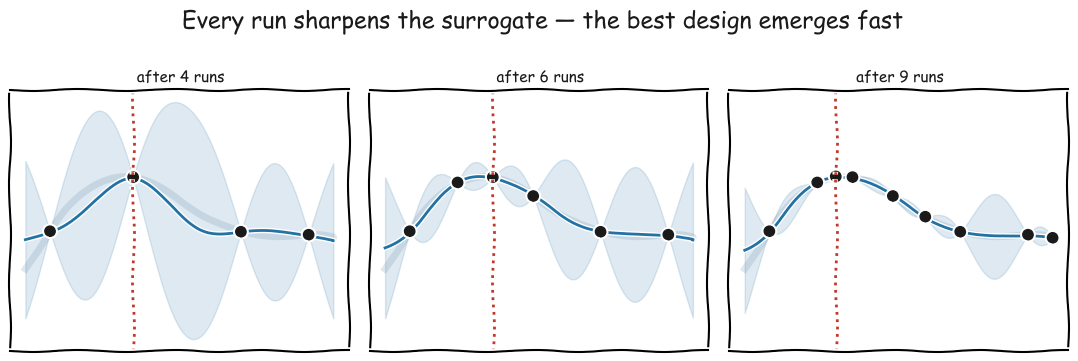

In [13]:
with plt.xkcd():
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
    for ax, extra in zip(axes, [0, 2, 5]):
        cx = [0.08, 0.35, 0.7, 0.92]
        for _ in range(extra):                       # greedily add points via the acquisition
            m, s = gp_posterior(np.array(cx), true_objective(np.array(cx)), X)
            cx.append(X[np.argmax(m + 1.8 * s)])
        cx = np.array(cx); cy = true_objective(cx)
        m, s = gp_posterior(cx, cy, X)
        ax.plot(X, true_objective(X), color="#cfd8e3", lw=5, alpha=0.6, zorder=0)
        ax.fill_between(X, m - 2*s, m + 2*s, color=BLUE, alpha=0.15)
        ax.plot(X, m, color=BLUE, lw=2)
        ax.plot(cx, cy, "o", color=INK, ms=7)
        ax.axvline(cx[np.argmax(cy)], color=RED, ls=":")     # best design so far
        ax.set_title(f"after {len(cx)} runs", color=INK, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Every run sharpens the surrogate — the best design emerges fast", color=INK)
    plt.tight_layout(); plt.show()

## 6. TPE — the engine we actually use

[Optuna](https://optuna.org)'s default sampler is the **Tree-structured Parzen Estimator (TPE)**. It reaches the *same* goal as the GP + acquisition picture, by a different, cheaper route. Every word in the name earns its place:

- **Parzen estimator** = **kernel density estimation**. Instead of fitting a function like a GP, you estimate a probability density *directly*: drop a small smooth bump on each observed point and add them up. Tall where data clusters, near-zero where there's none. No matrix solve.
- **Tree-structured** = it can model **conditional** search spaces (parameters that only exist depending on others — *"if optimiser = Adam, then also a beta"*). We don't need that for our 3 always-present variables, but it's why TPE is the default for messy real-world spaces.

**The mechanism.** Sort the trials by objective and split them: the best fraction **γ** goes into the *good* pile, the rest into the *other* pile. Fit a density to each:

- **`l(x)`** — density of **good** designs
- **`g(x)`** — density of **everything else**

A promising candidate scores **high on `l(x)`** and **low on `g(x)`** — it looks like the winners and unlike the losers. So the score is simply the ratio **`l(x) / g(x)`**.

> **The connection to Section 4:** maximising `l(x)/g(x)` is *mathematically equivalent* to maximising **Expected Improvement**. TPE is genuinely Bayesian optimization — same acquisition target, densities instead of a GP.

**How it picks:** draw many candidates *from* `l(x)` (already biased to good regions), score each by the ratio, keep the best — no gradients, no inner optimisation. The first ~10 trials are random to seed the two densities, then the machinery switches on. And because it's density-based, an **integer `N`** needs no special kernel — it just builds a histogram-style density. Mixed int/continuous spaces work out of the box.


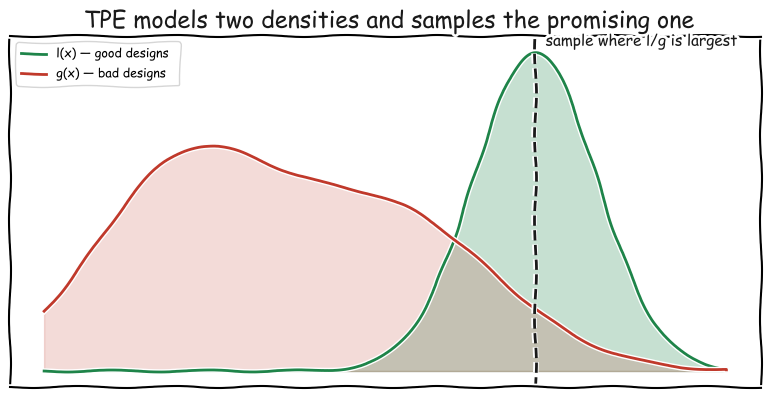

In [14]:
xx = np.linspace(0, 1, 400)
good = np.exp(-0.5 * ((xx - 0.72) / 0.09) ** 2)                               # l(x): good designs
bad  = 0.6*np.exp(-0.5*((xx-0.2)/0.13)**2) + 0.5*np.exp(-0.5*((xx-0.5)/0.16)**2)  # g(x): bad designs

with plt.xkcd():
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.fill_between(xx, good, color=GREEN, alpha=0.25)
    ax.plot(xx, good, color=GREEN, lw=2, label="l(x) — good designs")
    ax.fill_between(xx, bad, color=RED, alpha=0.18)
    ax.plot(xx, bad, color=RED, lw=2, label="g(x) — bad designs")
    ax.axvline(0.72, color=INK, ls="--")
    ax.text(0.72 + 0.015, 1.02, "sample where l/g is largest", color=INK, fontsize=11)
    ax.set_title("TPE models two densities and samples the promising one", color=INK)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout(); plt.show()

## 7. Why this tool — and what it can't do

No optimiser is magic, so it's worth being honest about both sides.

**Why Optuna / TPE (practical reasons):**

- Handles our **mixed** space (integer `N` + continuous `t`, `H`) with zero special setup.
- **Resumable**: every trial is written to a small SQLite file, so a crash costs nothing.
- Has a **pruner**: it can kill a hopeless trial (e.g. an invalid geometry) *before* paying for the CFD run.
- **Good defaults** — we don't hand-tune the optimiser, which would just move the problem.

**What it can't do (the honest limits):**

1. **No global-optimum guarantee.** It's a smart heuristic, not a proof — it can settle into a good region and stop looking. Random start-up trials and a reasonable budget reduce, but never remove, this risk.
2. **Needs enough evaluations.** The belief is only as good as the data behind it. ~30 runs is fine for 3 variables; it would be far too thin for 10–20.
3. **Sensitive to noise.** If a CFD run hasn't fully converged and reports a slightly wrong Q/V, the model treats that noise as signal.
4. **Only as good as the objective.** We optimise Q/V from a *steady* run with a *fixed wall temperature* — a deliberate, cheap, fair-for-comparison simplification, but **not** the full physics.

> This is exactly why we don't stop at the optimiser's number. **Episode 6** re-runs the winning design as a **conjugate heat transfer (CHT)** simulation — real solid conduction and a realistic thermal boundary — to check whether the gain survives a harder, more honest test. *Optimisation proposes; validation disposes.*


## 8. How we apply it to the heatsink

| Piece of the theory | In our study |
|---|---|
| **Objective** | Maximise **Q/V** (heat dissipated per unit solid volume) |
| **Search space** | `N` ∈ 3–11 fins (int), `t` ∈ 1–3 mm, `H` ∈ 10–30 mm |
| **Sampler** | Optuna **TPE** — handles the mixed int/continuous space |
| **Warm start** | Seed the study with the best **Phase‑1 sweep** points |
| **Constraints** | **Prune** designs that violate manufacturability (min wall / gap) |
| **Storage** | **SQLite** study → resumable, every trial logged |
| **One evaluation** | Generate STL → snappyHexMesh → `buoyantSimpleFoam` → read Q/V |

Same loop as the cartoon above — only now each "sample" is a real CFD run on the VM.


## 9. What to expect in Episode 5

Now that the theory is clear, **Episode 5** wires it up for real: the Optuna driver, the manufacturability pruning, the resumable SQLite study, and the full automated loop chewing through CFD runs on the VM — until it lands on the optimal design (**N = 11, t ≈ 1.0 mm, H ≈ 23.7 mm → Q/V ≈ 2.0, an +87 % gain**).

➡️ Continue to [`episode-05-optimization-loop/`](../episode-05-optimization-loop/)
